# Support Vector Classification

## Ramesh and the tea stall

Ramesh runs a tea stall on a long straight highway.

He wants to print leaflets, but only for the households that will actually walk
over and buy tea. Printing for everyone costs too much. So he needs to predict,
for a household he has not visited yet: **will this one stop or not?**

He has exactly one number for each household — where it sits on the highway,
measured from his stall. West is negative, east is positive. `-7` means seven
units west, `+7` means seven units east.

He collects fifteen records and tries the simplest rule he can think of:

> "Everyone from some point onward will stop."

It fails. Not slightly — whatever cut-off he picks, he gets at least four of the
fifteen households wrong.

## Why it fails

Ramesh's data is not noisy. His two groups do not even touch: every household
that stops is within 3 units of the stall, every household that does not is 4 or
more away.

The problem is the **question**. He asked *which side of me is this household on?*
But the households that stop are the ones that live **close** — and close means
close on **both** sides. His single cut-off has to hand one whole side to each
answer, so it can never describe "the middle".

## The fix

Not a bigger model. One better column: **distance** from the stall instead of
**side**. Squaring his number does exactly that — it throws away east-versus-west
and keeps only how far.

```text
position (west -, east +)   ->  no single cut-off works
position squared = distance ->  near and far separate cleanly
SVC                         ->  places the cut in the safest spot in the gap
```

This is a classification problem: the answer is a category (`0` = does not stop,
`1` = stops), not a number.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
D1 = np.array([[-7,0],[-6,0],[-5,0],[-4,0],[4,0],[5,0],[6,0],[7,0]])

In [3]:
D2 = np.array([[-3,0],[-2,0],[-1,0],[0,0],[1,0],[2,0],[3,0]])

## Step 1: Ramesh's fifteen records

`D1` and `D2` hold the two groups.

- `D1` — households that did **not** stop: positions `-7` to `-4`, and `4` to `7`  ->  class `0`
- `D2` — households that **did** stop: positions `-3` to `3`  ->  class `1`

Both arrays carry a second column that is always `0`. That becomes `X2`. Ramesh
only ever measured one thing, so this column holds no information and the data
really lives on a single axis.

Before running the next cell, be Ramesh for a moment: **pick one cut-off on the
highway, say everything below it stops and everything above it does not.** Then
count how many of the fifteen you got wrong.

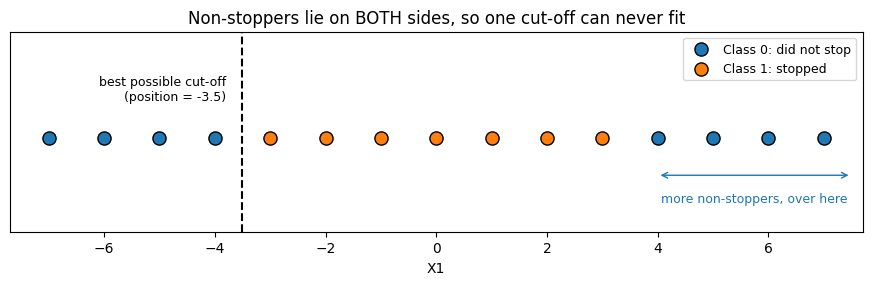

Best possible cut-off: 11 of 15 correct (73%)
The failure is structural, not a tuning problem.


In [4]:
# Ramesh's highway, drawn as a number line.
# Then: what is the BEST cut-off that exists? Not a guessed one - search
# every possible cut-off and keep the one that gets the most right.
x_all = np.concatenate([D1[:, 0], D2[:, 0]])
y_all = np.concatenate([np.zeros(len(D1)), np.ones(len(D2))])

best_cut, best_correct = None, -1
for cut in np.arange(-8, 8.5, 0.5):
    # try the rule both ways round, so we are not accidentally handicapping it
    for pred in (np.where(x_all < cut, 1, 0), np.where(x_all < cut, 0, 1)):
        correct = (pred == y_all).sum()
        if correct > best_correct:
            best_correct, best_cut = correct, cut

plt.figure(figsize=(11, 2.6))
plt.scatter(D1[:, 0], np.zeros(len(D1)), s=90, color='tab:blue',
            edgecolor='black', label='Class 0: did not stop')
plt.scatter(D2[:, 0], np.zeros(len(D2)), s=90, color='tab:orange',
            edgecolor='black', label='Class 1: stopped')
plt.axvline(best_cut, color='black', linestyle='--', linewidth=1.5)
plt.text(best_cut - 0.3, 0.22, f'best possible cut-off\n(position = {best_cut})',
         ha='right', fontsize=9)
plt.annotate('', xy=(7.5, -0.22), xytext=(4, -0.22),
             arrowprops=dict(arrowstyle='<->', color='tab:blue'))
plt.text(5.75, -0.38, 'more non-stoppers, over here', ha='center',
         fontsize=9, color='tab:blue')
plt.yticks([])
plt.ylim(-0.55, 0.62)
plt.xlabel('X1')
plt.title("Non-stoppers lie on BOTH sides, so one cut-off can never fit")
plt.legend(loc='upper right', fontsize=9)
plt.show()

print(f'Best possible cut-off: {best_correct} of {len(y_all)} correct '
      f'({best_correct / len(y_all):.0%})')
print('The failure is structural, not a tuning problem.')

In [5]:
a,b=D1[:,0],D1[:,1]
c,d=D2[:,0],D2[:,1]

In [6]:
#dff1 =pd.DataFrame(np.hstack([a,b]).T,columns=['X1','X2'])
dff1 =pd.DataFrame(np.vstack([a,b]).T,columns=['X1','X2'])
dff1['Y']=0
dff1

,X1,X2,Y
0,-7,0,0
1,-6,0,0
2,-5,0,0
3,-4,0,0
4,4,0,0
5,5,0,0
6,6,0,0
7,7,0,0


In [7]:
dff2 =pd.DataFrame(np.vstack([c,d]).T,columns=['X1','X2'])
dff2['Y']=1
dff2

,X1,X2,Y
0,-3,0,1
1,-2,0,1
2,-1,0,1
3,0,0,1
4,1,0,1
5,2,0,1
6,3,0,1


In [8]:
final = pd.concat([dff1, dff2], ignore_index=True)

In [9]:
final

,X1,X2,Y
0,-7,0,0
1,-6,0,0
2,-5,0,0
3,-4,0,0
4,4,0,0
5,5,0,0
6,6,0,0
7,7,0,0
8,-3,0,1
9,-2,0,1


In [10]:
final['X1_Square']= final['X1']**2
final

,X1,X2,Y,X1_Square
0,-7,0,0,49
1,-6,0,0,36
2,-5,0,0,25
3,-4,0,0,16
4,4,0,0,16
5,5,0,0,25
6,6,0,0,36
7,7,0,0,49
8,-3,0,1,9
9,-2,0,1,4


## Step 2: Ramesh asks a better question

His original column answers: *is this household west or east of me?*

Wrong question. Whether someone walks over depends on something else entirely:
*how far away are they?*

Squaring answers that. It throws the direction away and keeps the distance:

| position | -7 | -4 | -3 | 0 | 3 | 4 | 7 |
|---|---|---|---|---|---|---|---|
| squared | 49 | 16 | 9 | 0 | 9 | 16 | 49 |

Now look at where each group lands in the new column:

- households that **stop** occupy `0, 1, 4, 9`
- households that **do not** occupy `16, 25, 36, 49`

Nothing sits between `9` and `16`. That empty band of width `7` is what makes the
problem solvable, and it is what SVC will aim at.

Notice what did **not** change: the classifier. Ramesh changed the column he hands
it. That is feature engineering.

## Step 3: What is SVC actually looking for?

Before handing Ramesh's data over, look at an easier case — one where a straight
boundary already works — so you can see what the model is choosing.

Lakshmi owns a fruit farm. For each field she has recorded two things, and whether
**apples** or **oranges** grew better there. Her two groups sit apart cleanly, so
many different straight lines would separate them.

Which line should she use? A line squeezed right up against the apple fields is
technically correct, but the first new field that lands slightly off gets
misclassified. SVC picks the line with the **most room on both sides**.

Three names for the three things in the picture below:

- the **hyperplane** is the boundary itself, $w^\top x + b = 0$ — the solid line;
- the two **margin** lines sit at $w^\top x + b = \pm 1$ — the dotted lines;
- the points touching those dotted lines are the **support vectors**.

The last one is the surprising part. Only those few points hold the boundary in
place. Every other field could move, or be deleted, and the line would not shift.

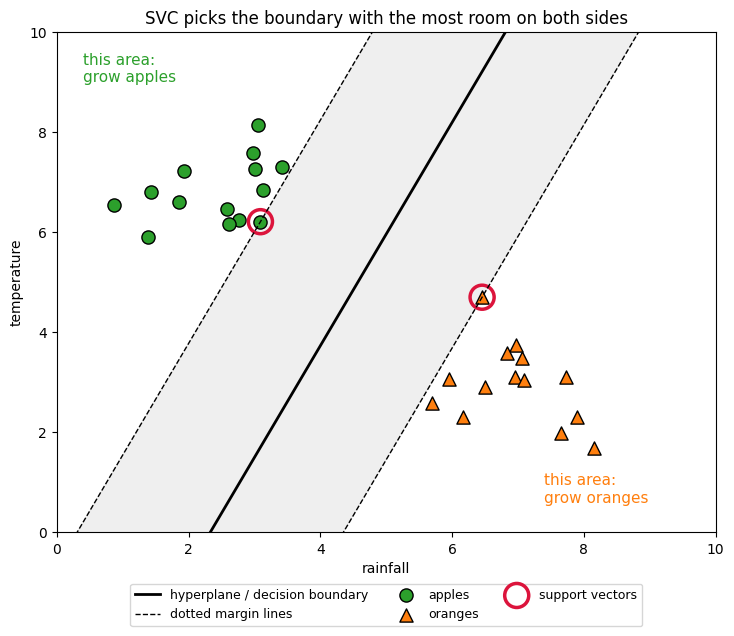

margin width   : 3.69
support vectors: 2 out of 28 points
Every other point could be moved and the boundary would not shift.


In [11]:
# Lakshmi's farm: the easy case, where a straight boundary already works.
# One hyperplane, two dotted margin lines, and the support vectors holding it.
from sklearn.svm import SVC

rng = np.random.default_rng(7)
apples = rng.normal(loc=[3.0, 7.0], scale=0.85, size=(14, 2))
oranges = rng.normal(loc=[7.0, 3.0], scale=0.85, size=(14, 2))

fruit_X = np.vstack([apples, oranges])
fruit_y = np.r_[np.zeros(len(apples)), np.ones(len(oranges))]

fruit_svc = SVC(kernel='linear', C=1e6).fit(fruit_X, fruit_y)
w, b = fruit_svc.coef_[0], fruit_svc.intercept_[0]

line_x = np.linspace(0, 10, 100)
boundary = -(w[0] * line_x + b) / w[1]          # w.x + b =  0
margin_up = -(w[0] * line_x + b - 1) / w[1]     # w.x + b = +1
margin_dn = -(w[0] * line_x + b + 1) / w[1]     # w.x + b = -1

fig, ax = plt.subplots(figsize=(8.5, 6.5))
ax.fill_between(line_x, margin_dn, margin_up, color='gray', alpha=0.12)
ax.plot(line_x, boundary, color='black', linewidth=2,
        label='hyperplane / decision boundary')
ax.plot(line_x, margin_up, color='black', linestyle='--', linewidth=1,
        label='dotted margin lines')
ax.plot(line_x, margin_dn, color='black', linestyle='--', linewidth=1)

ax.scatter(apples[:, 0], apples[:, 1], s=90, marker='o', color='tab:green',
           edgecolor='black', label='apples')
ax.scatter(oranges[:, 0], oranges[:, 1], s=90, marker='^', color='tab:orange',
           edgecolor='black', label='oranges')
ax.scatter(fruit_svc.support_vectors_[:, 0], fruit_svc.support_vectors_[:, 1],
           s=300, facecolors='none', edgecolors='crimson', linewidths=2.5,
           label='support vectors')

ax.text(0.4, 9.0, 'this area:\ngrow apples', fontsize=11, color='tab:green')
ax.text(7.4, 0.6, 'this area:\ngrow oranges', fontsize=11, color='tab:orange')

ax.set_xlim(0, 10)
ax.set_ylim(0, 10)
ax.set_xlabel('rainfall')
ax.set_ylabel('temperature')
ax.set_title('SVC picks the boundary with the most room on both sides')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.09), ncol=3, fontsize=9)
plt.show()

print(f'margin width   : {2 / np.linalg.norm(w):.2f}')
print(f'support vectors: {len(fruit_svc.support_vectors_)} out of {len(fruit_X)} points')
print('Every other point could be moved and the boundary would not shift.')

## Step 4: When one new column is not enough

Ramesh's problem needed exactly one new column, because he only ever measured one
thing. Suppose he moves to a town and starts recording two numbers per household —
how far east and how far north of the stall it is.

Now the households that stop form a **blob around the stall**, and the ones that
do not form a **ring around them**. On a flat map no straight line can separate a
blob from the ring around it. Any line you draw cuts straight through both.

The escape is the same trick, one size up:

| Measurements | Add | Ends up |
|---|---|---|
| 1 (position) | $x_1^2$ | 2D — this notebook |
| 2 (east, north) | $x_1^2 + x_2^2$ | 3D — the figure below |

The new column is still just distance. It lifts the ring high and leaves the blob
on the floor, and a flat plane slides into the space between them.

### Doing this without building the columns by hand

Two measurements are easy. But a full degree-2 expansion of two features already
produces five new columns:

$$
x_1^2,\quad x_1x_2,\quad x_2^2,\quad x_1,\quad x_2
$$

With ten features it is unmanageable. A **kernel** computes the answer *as if*
those columns existed, without ever building them:

$$
K(x, z) = (x^\top z + 1)^d
$$

At $d = 2$ that is exactly the five-column view above. `kernel='poly'` gives you
polynomial columns, `kernel='rbf'` gives a more flexible curved view.

Ramesh needs neither. With his second column stuck at zero, every term containing
$x_2$ — that is $x_1x_2$ and $x_2^2$ — collapses to zero too. The only new feature
that survives is $x_1^2$, and that is the one column we built by hand.

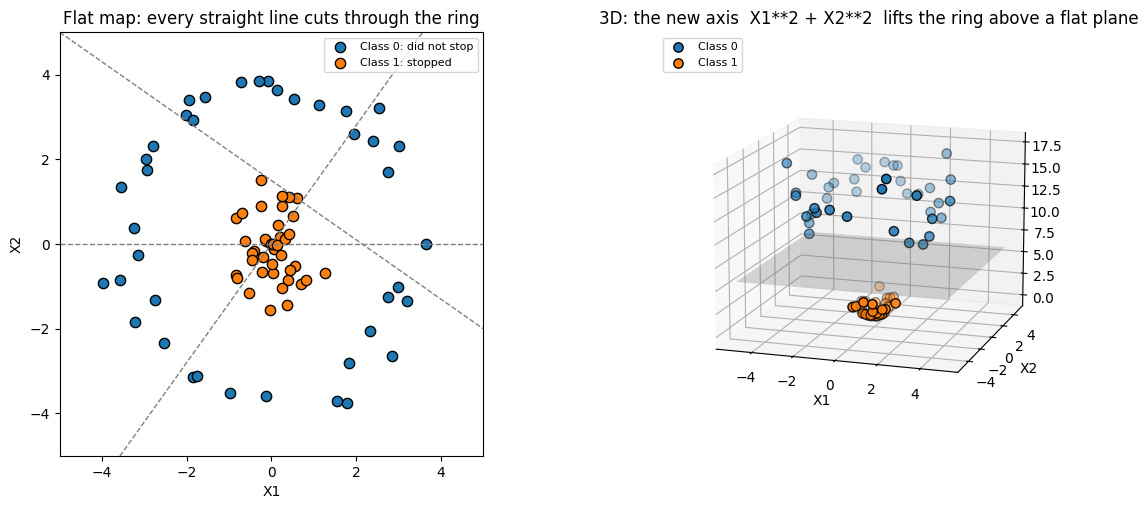

best straight line in 2D : 74% correct
flat plane in 3D         : 100% correct
the plane sits at X1**2 + X2**2 = 5.78, in the gap between 2.43 and 9.14


In [12]:
# Ramesh in town: two measurements per household instead of one.
# The households that stop form a blob around the stall, the rest form a ring.
# Same trick as before, one size up: add X1**2 + X2**2.
rng = np.random.default_rng(3)

inner_r, inner_t = rng.uniform(0.0, 1.6, 40), rng.uniform(0, 2 * np.pi, 40)
inner = np.c_[inner_r * np.cos(inner_t), inner_r * np.sin(inner_t)]

outer_r, outer_t = rng.uniform(3.0, 4.2, 40), rng.uniform(0, 2 * np.pi, 40)
outer = np.c_[outer_r * np.cos(outer_t), outer_r * np.sin(outer_t)]

inner_z = (inner ** 2).sum(axis=1)
outer_z = (outer ** 2).sum(axis=1)

fig = plt.figure(figsize=(13, 5.5))

# Left: the 2D view. Try a few straight lines - every one of them fails.
ax1 = fig.add_subplot(1, 2, 1)
ax1.scatter(outer[:, 0], outer[:, 1], s=55, color='tab:blue',
            edgecolor='black', label='Class 0: did not stop')
ax1.scatter(inner[:, 0], inner[:, 1], s=55, color='tab:orange',
            edgecolor='black', label='Class 1: stopped')
for slope, offset in [(0.0, 0.0), (1.4, 0.0), (-0.7, 1.5)]:
    ax1.plot([-5, 5], [-5 * slope + offset, 5 * slope + offset],
             color='gray', linestyle='--', linewidth=1)
ax1.set_xlim(-5, 5)
ax1.set_ylim(-5, 5)
ax1.set_aspect('equal')
ax1.set_xlabel('X1')
ax1.set_ylabel('X2')
ax1.set_title('Flat map: every straight line cuts through the ring')
ax1.legend(loc='upper right', fontsize=8)

# Right: add the third axis. Now a flat plane fits in the gap.
ax2 = fig.add_subplot(1, 2, 2, projection='3d')
ax2.scatter(outer[:, 0], outer[:, 1], outer_z, s=45, color='tab:blue',
            edgecolor='black', label='Class 0')
ax2.scatter(inner[:, 0], inner[:, 1], inner_z, s=45, color='tab:orange',
            edgecolor='black', label='Class 1')

plane_at = (inner_z.max() + outer_z.min()) / 2
pg = np.linspace(-5, 5, 12)
pgx, pgy = np.meshgrid(pg, pg)
ax2.plot_surface(pgx, pgy, np.full_like(pgx, plane_at), alpha=0.25, color='gray')

ax2.set_xlabel('X1')
ax2.set_ylabel('X2')
ax2.set_box_aspect(None, zoom=0.90)
ax2.view_init(elev=14, azim=-72)   # look almost edge-on, so the lift is visible
ax2.set_title('3D: the new axis  X1**2 + X2**2  lifts the ring above a flat plane')
ax2.legend(loc='upper left', fontsize=8)

fig.subplots_adjust(left=0.06, right=0.97, wspace=0.02)
plt.show()

flat_2d = SVC(kernel='linear').fit(np.vstack([outer, inner]),
                                   np.r_[np.zeros(40), np.ones(40)])
lifted = SVC(kernel='linear', C=1e6).fit(
    np.c_[np.vstack([outer, inner]), np.r_[outer_z, inner_z]],
    np.r_[np.zeros(40), np.ones(40)])
print(f'best straight line in 2D : {flat_2d.score(np.vstack([outer, inner]), np.r_[np.zeros(40), np.ones(40)]):.0%} correct')
print(f'flat plane in 3D         : {lifted.score(np.c_[np.vstack([outer, inner]), np.r_[outer_z, inner_z]], np.r_[np.zeros(40), np.ones(40)]):.0%} correct')
print(f'the plane sits at X1**2 + X2**2 = {plane_at:.2f}, in the gap between '
      f'{inner_z.max():.2f} and {outer_z.min():.2f}')

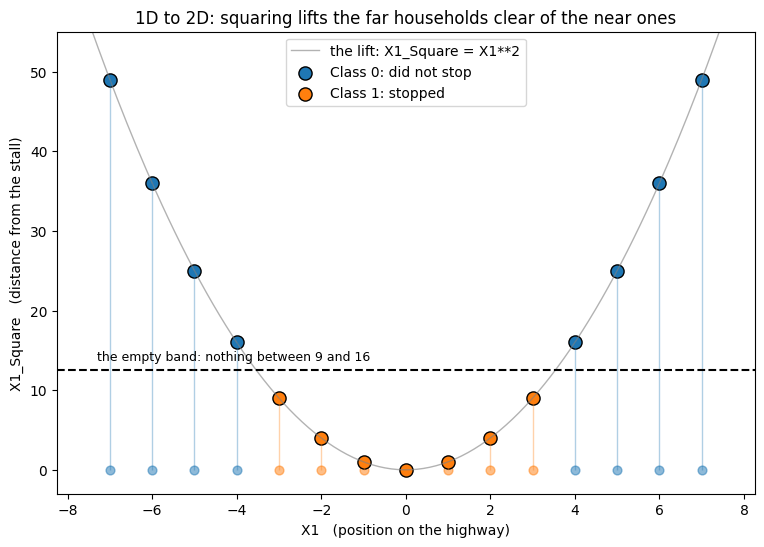

In [13]:
# What squaring does to Ramesh's highway: 1D -> 2D.
# Position alone is one axis. Adding position-squared gives a second axis,
# and every household rises onto a parabola - near ones stay low, far ones go high.
fig, ax = plt.subplots(figsize=(9, 6))

curve_x = np.linspace(-7.5, 7.5, 200)
ax.plot(curve_x, curve_x ** 2, color='gray', linewidth=1, alpha=0.6,
        label='the lift: X1_Square = X1**2')

class_0 = final[final['Y'] == 0]
class_1 = final[final['Y'] == 1]

# Show each point starting on the number line and rising to where it lands.
for frame, colour in [(class_0, 'tab:blue'), (class_1, 'tab:orange')]:
    ax.vlines(frame['X1'], 0, frame['X1_Square'], colors=colour,
              alpha=0.35, linewidth=1)
    ax.scatter(frame['X1'], np.zeros(len(frame)), s=40, color=colour, alpha=0.5)

ax.scatter(class_0['X1'], class_0['X1_Square'], s=90, color='tab:blue',
           edgecolor='black', label='Class 0: did not stop')
ax.scatter(class_1['X1'], class_1['X1_Square'], s=90, color='tab:orange',
           edgecolor='black', label='Class 1: stopped')

ax.axhline(12.5, color='black', linestyle='--', linewidth=1.5)
ax.text(-7.3, 13.8, 'the empty band: nothing between 9 and 16', fontsize=9)

ax.set_xlabel('X1   (position on the highway)')
ax.set_ylabel('X1_Square   (distance from the stall)')
ax.set_ylim(-3, 55)
ax.set_title('1D to 2D: squaring lifts the far households clear of the near ones')
ax.legend(loc='upper center')
plt.show()

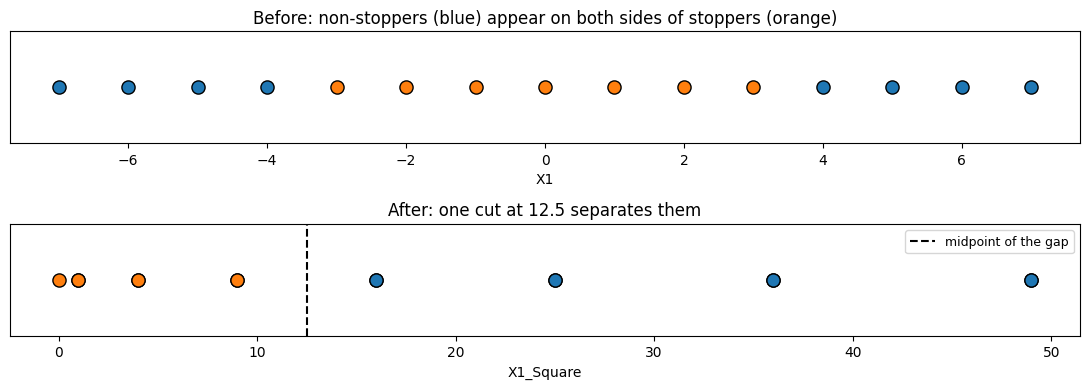

In [14]:
# How this plot is drawn, and why.
#
# It is tempting to put the class label on the Y axis. Do not. The two classes
# then sit on separate rows automatically, so BOTH panels look separated even
# when the feature is useless - you would be plotting the answer.
#
# Here the class is shown by colour only. Any separation you can see has to
# come from the X axis alone, which is the thing being compared.
class_0 = final[final['Y'] == 0]
class_1 = final[final['Y'] == 1]

fig, axes = plt.subplots(2, 1, figsize=(11, 4.0))

panels = [
    (axes[0], 'X1', 'Before: non-stoppers (blue) appear on both sides of stoppers (orange)'),
    (axes[1], 'X1_Square', 'After: one cut at 12.5 separates them'),
]
for ax, column, title in panels:
    ax.scatter(class_0[column], np.zeros(len(class_0)), s=90,
               color='tab:blue', edgecolor='black')
    ax.scatter(class_1[column], np.zeros(len(class_1)), s=90,
               color='tab:orange', edgecolor='black')
    ax.set_xlabel(column)
    ax.set_title(title)
    ax.set_yticks([])

axes[1].axvline(12.5, color='black', linestyle='--', label='midpoint of the gap')
axes[1].legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

## Step 5: Hand Ramesh's data to SVC

Now we give SVC both columns, position and position-squared, and let it search.

`SVC(kernel='linear', C=1e6)` means: find a straight boundary, and use a very
large `C` so the model is not allowed to trade mistakes for a wider margin. The
groups are cleanly separated, so demanding zero mistakes is safe here.

Two things to check in the output:

1. **The weight on the original position column should come out at essentially
   zero.** If it does, SVC worked out by itself that east-versus-west is useless,
   and the boundary is the flat line `X1_Square = 12.5` we predicted in Step 2.
2. **There should be exactly four support vectors**, at positions `-4, -3, 3, 4` —
   the households on either edge of the empty band. Every other household could
   move without shifting Ramesh's rule.

### One caution about reading the picture

The margin is a **geometric distance**, but the two axes are not on the same
scale: position spans about 16 units while position-squared spans about 54.
Matplotlib stretches both to fill the same square box, so the dotted margin lines
will look much narrower than they are. Trust the printed numbers.

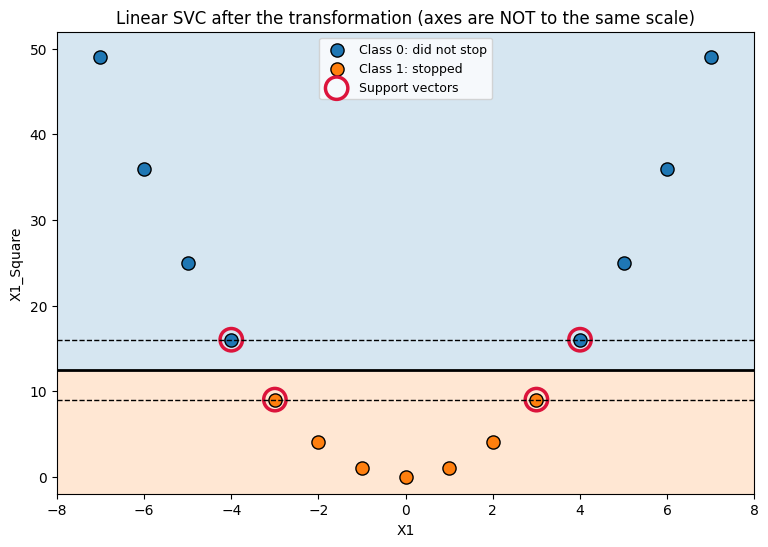

learned boundary : (-6.11e-17) * X1 + (-0.286) * X1_Square + (+3.57) = 0
weight on X1     : -6.11e-17  -> effectively zero, X1 is ignored
so the boundary is the flat line  X1_Square = 12.50
margin half-width: 3.50 in X1_Square units (the band from 9 to 16)
support vectors  : 4
[[-4. 16.]
 [ 4. 16.]
 [-3.  9.]
 [ 3.  9.]]
training accuracy: 100%


In [15]:
from sklearn.svm import SVC

X = final[['X1', 'X1_Square']]
y = final['Y']

svc_linear = SVC(kernel='linear', C=1e6)
svc_linear.fit(X, y)

# Build a grid so we can see the regions learned by the classifier.
x1_grid = np.linspace(-8, 8, 300)
x1_square_grid = np.linspace(-2, 52, 300)
grid_x1, grid_x1_square = np.meshgrid(x1_grid, x1_square_grid)
grid = pd.DataFrame(
    np.c_[grid_x1.ravel(), grid_x1_square.ravel()],
    columns=X.columns
)
decision_values = svc_linear.decision_function(grid).reshape(grid_x1.shape)

plt.figure(figsize=(9, 6))
plt.contourf(
    grid_x1,
    grid_x1_square,
    decision_values,
    levels=[-np.inf, 0, np.inf],
    alpha=0.18,
    colors=['tab:blue', 'tab:orange']
)
plt.contour(
    grid_x1,
    grid_x1_square,
    decision_values,
    levels=[-1, 0, 1],
    colors='black',
    linestyles=['--', '-', '--'],
    linewidths=[1, 2, 1]
)
plt.scatter(class_0['X1'], class_0['X1_Square'], s=90, color='tab:blue',
            edgecolor='black', label='Class 0: did not stop')
plt.scatter(class_1['X1'], class_1['X1_Square'], s=90, color='tab:orange',
            edgecolor='black', label='Class 1: stopped')
plt.scatter(
    svc_linear.support_vectors_[:, 0],
    svc_linear.support_vectors_[:, 1],
    s=260,
    facecolors='none',
    edgecolors='crimson',
    linewidths=2.5,
    label='Support vectors'
)
plt.xlabel('X1')
plt.ylabel('X1_Square')
plt.title('Linear SVC after the transformation (axes are NOT to the same scale)')
plt.legend(loc='upper center', fontsize=9)
plt.show()

# Read the model instead of eyeballing the plot.
w = svc_linear.coef_[0]
b = svc_linear.intercept_[0]
print(f'learned boundary : ({w[0]:+.3g}) * X1 + ({w[1]:+.3g}) * X1_Square + ({b:+.3g}) = 0')
print(f'weight on X1     : {w[0]:.2e}  -> effectively zero, X1 is ignored')
print(f'so the boundary is the flat line  X1_Square = {-b / w[1]:.2f}')
print(f'margin half-width: {1 / np.linalg.norm(w):.2f} in X1_Square units '
      f'(the band from 9 to 16)')
print(f'support vectors  : {len(svc_linear.support_vectors_)}')
print(svc_linear.support_vectors_)
print(f'training accuracy: {svc_linear.score(X, y):.0%}')

## What Ramesh learned

His data was never the problem. It was clean, and the two groups never overlapped.
A straight rule still failed, because the households that stop sit on **both sides**
of him, and one cut-off has to give a whole side to each answer.

Changing the question from *"which side?"* to *"how far?"* opened a gap between
`9` and `16`. SVC put its boundary in the middle of that gap and kept the four
edge households as support vectors. It ignored his original column completely —
you can read that straight off the fitted coefficient.

### Terms used here

| Term | Meaning in Ramesh's problem |
|---|---|
| `SVC` | Support Vector Classifier — predicts a category: stops / does not stop |
| `SVR` | Support Vector Regressor — predicts a number instead |
| Decision boundary | The rule itself: $w^\top x + b = 0$ |
| Margin | The empty band around it, here `9` to `16` |
| Support vector | A household on the edge of that band: positions `-4, -3, 3, 4` |
| `C` | How hard the model tries to avoid mistakes on the records it was given |
| Kernel | A way to get transformed columns without building them by hand |

### If you remember only one thing

> SVM does not look for *a* boundary that separates. It looks for the boundary
> with the widest empty band around it. And when no boundary can work, the fix is
> usually a better column, not a bigger model.

### Next experiment

Keep Ramesh's data fixed and change only the kernel: `linear`, `poly`, `rbf`. Give
each one the raw position column alone, with no squared column, and see which
kernels find the pattern on their own.